# Experiment 2B — Tail-risk classification

Saved event-label audit, classifier diagnostics, probability paths and Choquistic-capacity summaries.

In [1]:
from IPython.display import Image, Markdown, display
from mwc_experiments.reporting import load_result_table, result_figure_path

## Tail labels and point-in-time thresholds

### Event prevalence by horizon and confidence level
Check class imbalance before interpreting PR-AUC, thresholds or confusion matrices.

observations  events  event rate
alpha horizon                                  
0.950 1                2911     161    0.055307
      5                2903     169    0.058216
      10               2893     187    0.064639
0.975 1                2911      96    0.032978
      5                2903     104    0.035825
      10               2893     135    0.046664

### Point-in-time tail thresholds
Verify that event definitions adapt using past information rather than full-sample quantiles.

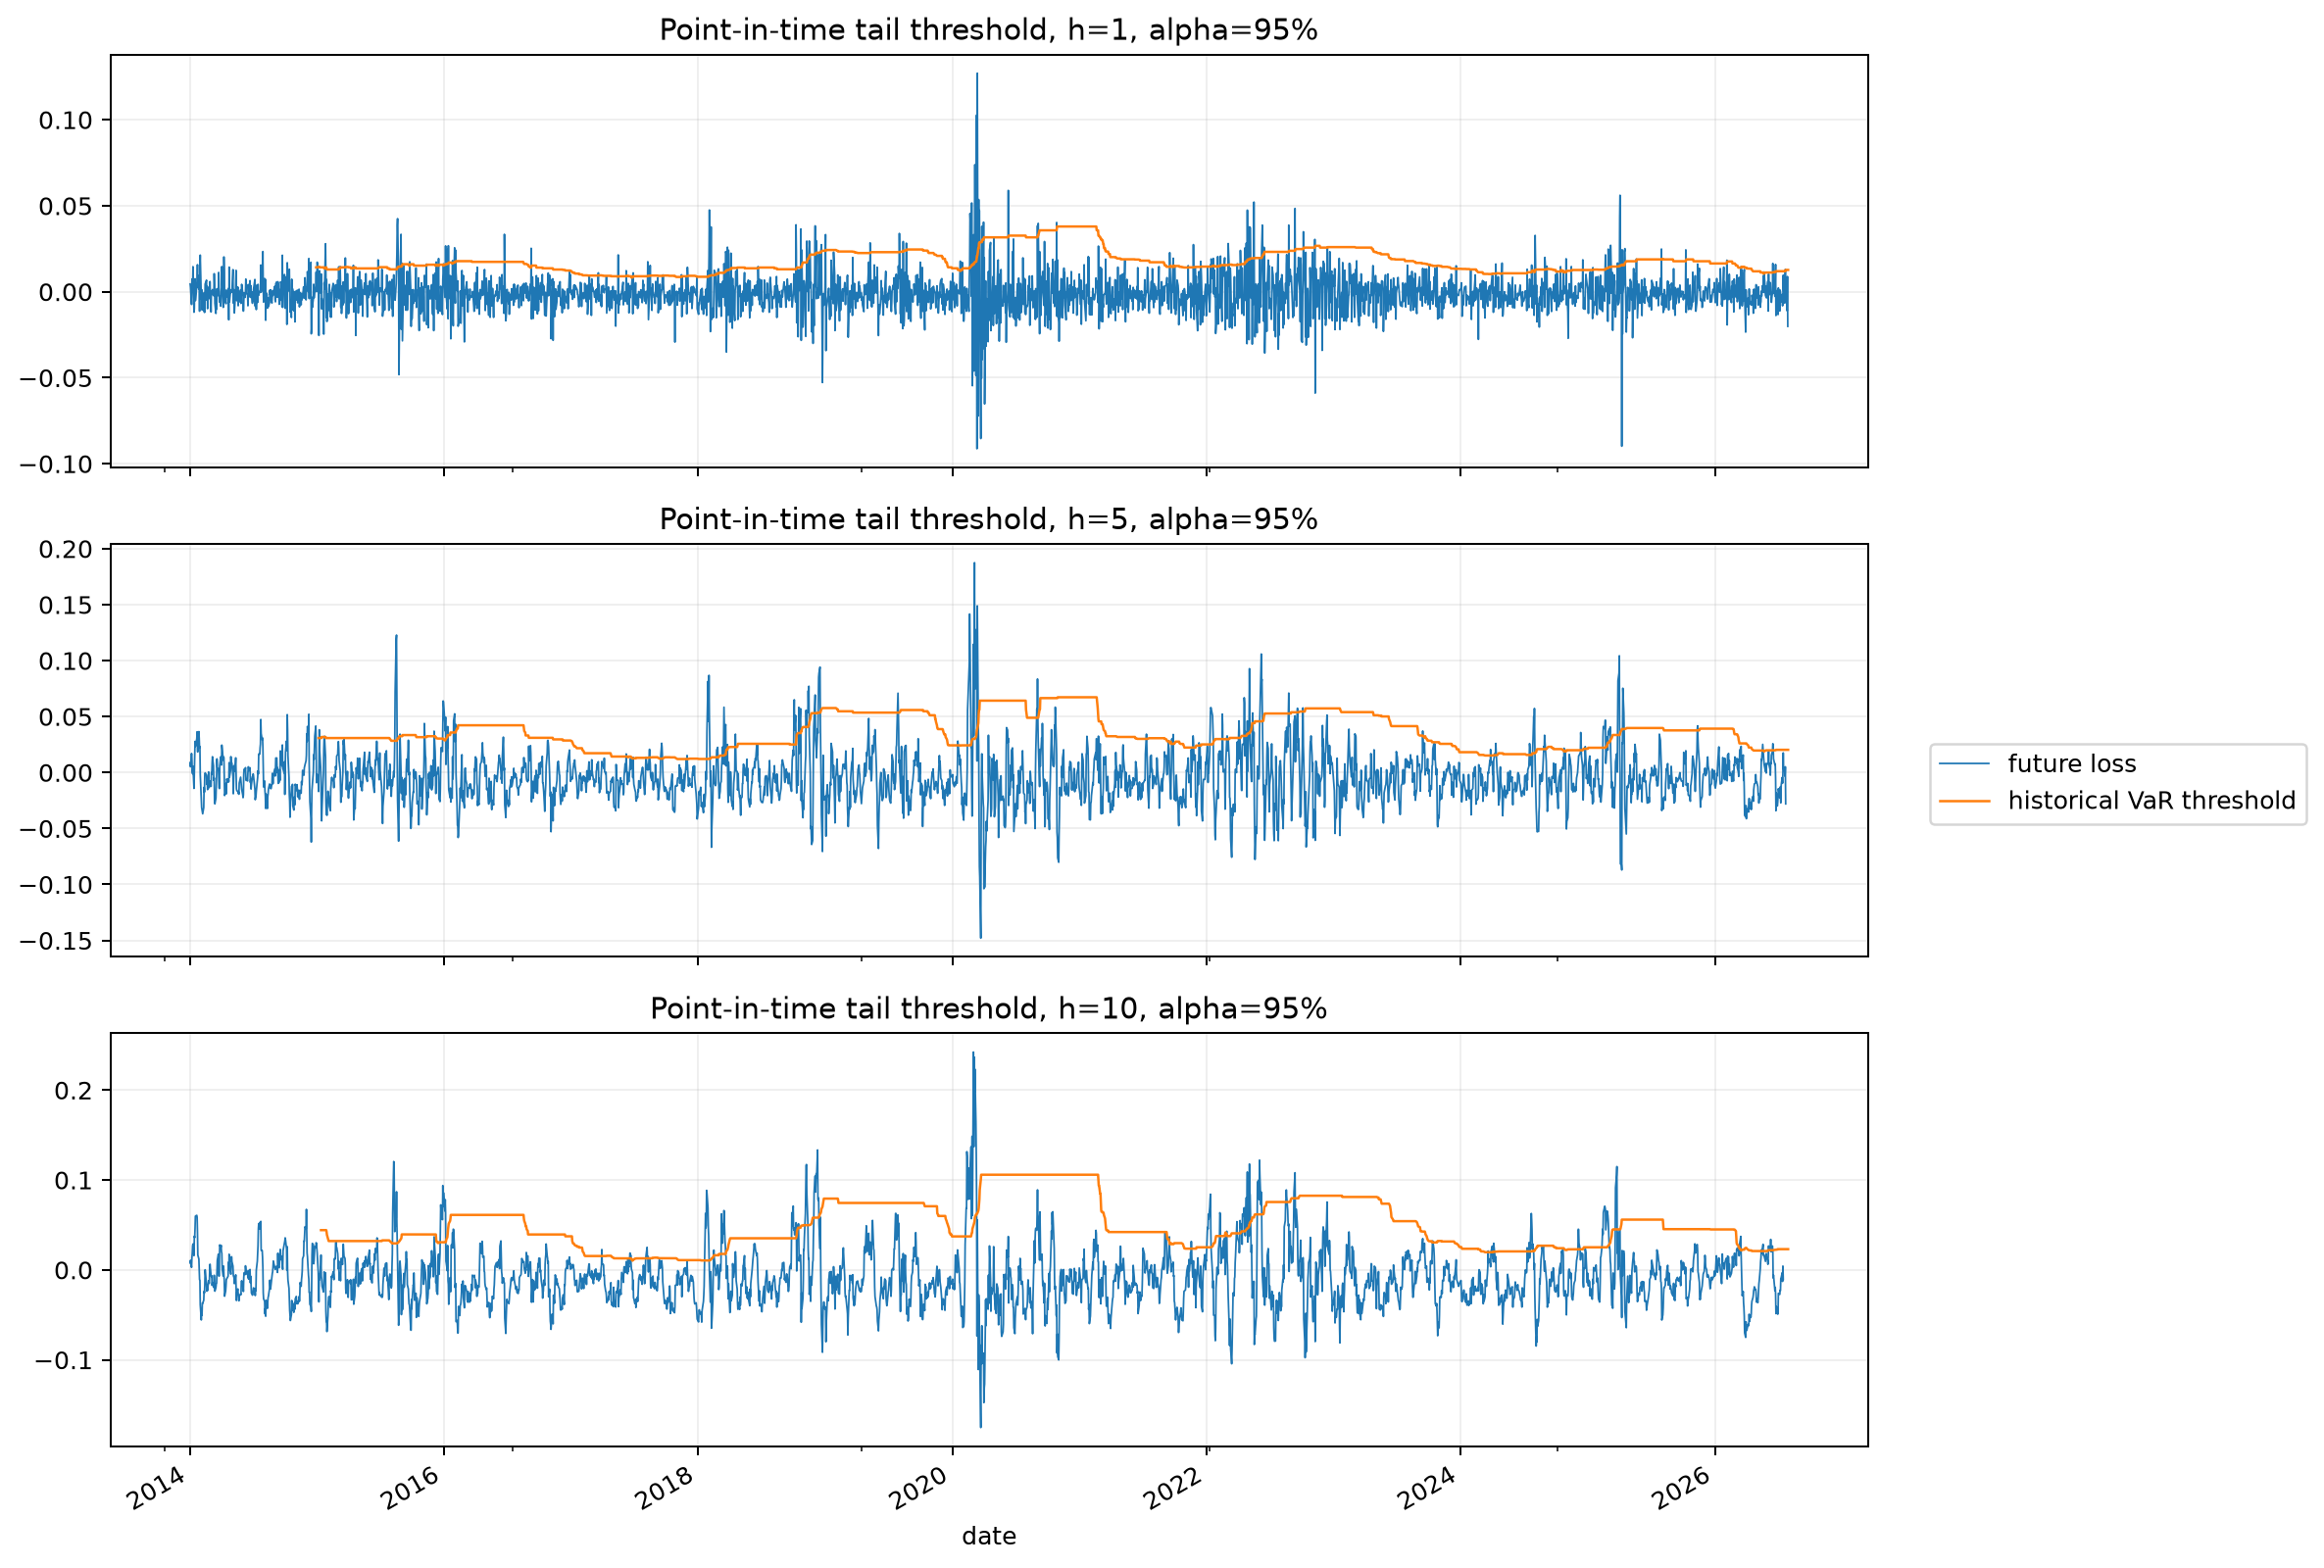

In [2]:
display(Markdown("### Event prevalence by horizon and confidence level\nCheck class imbalance before interpreting PR-AUC, thresholds or confusion matrices."))
display(load_result_table("experiment_2b_tail_label_audit.csv", index_col=[0, 1]))
display(Markdown("### Point-in-time tail thresholds\nVerify that event definitions adapt using past information rather than full-sample quantiles."))
display(Image(filename=result_figure_path("experiment_2b_tail_thresholds_a095.png")))

## Primary 95% classifier comparison

Discrimination (ROC-AUC and PR-AUC) and probability calibration (Brier, log loss and prevalence alignment) are reported separately. Every annual OOS block repeats training, chronological selection, refitting and frozen-pipeline calibration using only its preceding five-year window.

### Complete OOS metrics by horizon
Start with the combined view of discrimination, calibration and threshold-dependent classification.

,base model,probability calibration,threshold source,ROC AUC,PR AUC,Precision,Recall,F1,Brier,Log loss,...,Predicted event rate,Observed event rate,validation PR AUC,selection runtime seconds,refit runtime seconds,calibration runtime seconds,parameter count,calibration observations,calibration event prevalence,OOS folds
model,,,,,,,,,,,,,,,,,,,,,
Penalized logistic,Penalized logistic,uncalibrated,selection validation,0.616448,0.111499,0.085346,0.582418,0.148876,0.371484,0.991056,...,0.376136,0.055118,0.130553,0.519495,0.096403,0.000000,11.0,3514,0.055204,7
Choquistic 1-additive,Choquistic 1-additive,uncalibrated,selection validation,0.675275,0.110466,0.081670,0.494505,0.140187,0.235224,0.687176,...,0.333737,0.055118,0.109687,2.790279,3.193334,0.000000,12.0,3514,0.055204,7
Choquistic 2-additive,Choquistic 2-additive,uncalibrated,selection validation,0.642110,0.109582,0.076423,0.516484,0.133144,0.220630,0.655970,...,0.372502,0.055118,0.105780,16.078636,17.637605,0.000000,57.0,3514,0.055204,7
Logistic oriented [sigmoid],Logistic oriented,sigmoid,calibration,0.621210,0.108314,0.088073,0.527473,0.150943,0.053711,0.215139,...,0.330103,0.055118,0.109470,0.172931,0.104184,0.148325,11.0,3514,0.055204,7
Logistic [sigmoid],Logistic,sigmoid,calibration,0.621210,0.108314,0.088073,0.527473,0.150943,0.053711,0.215139,...,0.330103,0.055118,0.109470,0.076183,0.093637,0.131800,11.0,3514,0.055204,7
Logistic oriented [isotonic],Logistic oriented,isotonic,calibration,0.629318,0.103769,0.114504,0.494505,0.185950,0.075288,0.945959,...,0.238038,0.055118,0.109470,0.172931,0.104184,0.232760,11.0,3514,0.055204,7
Logistic [isotonic],Logistic,isotonic,calibration,0.629318,0.103769,0.114504,0.494505,0.185950,0.075288,0.945959,...,0.238038,0.055118,0.109470,0.076183,0.093637,0.101115,11.0,3514,0.055204,7
Penalized logistic [isotonic],Penalized logistic,isotonic,calibration,0.613912,0.101875,0.140684,0.406593,0.209040,0.053231,0.287259,...,0.159297,0.055118,0.130553,0.519495,0.096403,0.129363,11.0,3514,0.055204,7
Penalized logistic [sigmoid],Penalized logistic,sigmoid,calibration,0.597697,0.101867,0.095122,0.428571,0.155689,0.052242,0.211576,...,0.248334,0.055118,0.130553,0.519495,0.096403,0.144652,11.0,3514,0.055204,7


,base model,probability calibration,threshold source,ROC AUC,PR AUC,Precision,Recall,F1,Brier,Log loss,...,Predicted event rate,Observed event rate,validation PR AUC,selection runtime seconds,refit runtime seconds,calibration runtime seconds,parameter count,calibration observations,calibration event prevalence,OOS folds
model,,,,,,,,,,,,,,,,,,,,,
Random forest,Random forest,uncalibrated,selection validation,0.623859,0.192520,0.068576,0.892157,0.127362,0.160716,0.500515,...,0.805707,0.061931,0.062741,40.701776,7.102279,0.000000,NaN,3486,0.0617,7
Choquistic 1-additive,Choquistic 1-additive,uncalibrated,selection validation,0.649641,0.141444,0.065704,0.892157,0.122394,0.220611,0.636300,...,0.840923,0.061931,0.076485,2.979839,3.312571,0.000000,12.0,3486,0.0617,7
Choquistic 2-additive,Choquistic 2-additive,uncalibrated,selection validation,0.611457,0.131918,0.077107,0.950980,0.142647,0.222437,0.647911,...,0.763813,0.061931,0.058591,10.588717,10.296319,0.000000,57.0,3486,0.0617,7
Random forest [isotonic],Random forest,isotonic,calibration,0.648909,0.115113,0.097651,0.774510,0.173436,0.057673,0.255285,...,0.491196,0.061931,0.062741,40.701776,7.102279,2.353449,NaN,3486,0.0617,7
Logistic [sigmoid],Logistic,sigmoid,calibration,0.561254,0.101598,0.065392,0.637255,0.118613,0.064123,0.253230,...,0.603522,0.061931,0.090986,0.160986,0.086611,0.154319,11.0,3486,0.0617,7
Logistic oriented [sigmoid],Logistic oriented,sigmoid,calibration,0.561254,0.101598,0.065392,0.637255,0.118613,0.064123,0.253230,...,0.603522,0.061931,0.090986,0.154401,0.083382,0.129387,11.0,3486,0.0617,7
Penalized logistic [sigmoid],Penalized logistic,sigmoid,calibration,0.565493,0.097672,0.063353,0.637255,0.115248,0.064931,0.254469,...,0.622951,0.061931,0.107784,0.407460,0.081663,0.123301,11.0,3486,0.0617,7
RBF SVM [isotonic],RBF SVM,isotonic,calibration,0.593343,0.086359,0.083117,0.627451,0.146789,0.058109,0.414874,...,0.467517,0.061931,0.076890,1.543207,0.864370,0.325170,NaN,3486,0.0617,7
MLP,MLP,uncalibrated,selection validation,0.510502,0.080787,0.096091,0.578431,0.164804,0.099726,0.359513,...,0.372799,0.061931,0.085062,0.797801,0.212576,0.000000,NaN,3486,0.0617,7


,base model,probability calibration,threshold source,ROC AUC,PR AUC,Precision,Recall,F1,Brier,Log loss,...,Predicted event rate,Observed event rate,validation PR AUC,selection runtime seconds,refit runtime seconds,calibration runtime seconds,parameter count,calibration observations,calibration event prevalence,OOS folds
model,,,,,,,,,,,,,,,,,,,,,
Random forest [isotonic],Random forest,isotonic,calibration,0.595311,0.176088,0.079618,0.669643,0.142315,0.063024,0.464779,...,0.573691,0.06821,0.077927,27.752449,4.143653,1.347671,NaN,3451,0.067253,7
Choquistic 2-additive,Choquistic 2-additive,uncalibrated,selection validation,0.530573,0.128529,0.076068,0.794643,0.138846,0.237824,0.681655,...,0.712546,0.06821,0.082144,7.291612,8.318533,0.000000,57.0,3451,0.067253,7
MLP,MLP,uncalibrated,selection validation,0.491387,0.127795,0.065060,0.241071,0.102467,0.105001,0.377364,...,0.252741,0.06821,0.112278,0.624951,0.182793,0.000000,NaN,3451,0.067253,7
Logistic oriented [sigmoid],Logistic oriented,sigmoid,calibration,0.583759,0.117757,0.077957,0.776786,0.141694,0.101636,0.350057,...,0.679659,0.06821,0.075859,0.138126,0.067482,0.146269,11.0,3451,0.067253,7
Logistic [sigmoid],Logistic,sigmoid,calibration,0.583759,0.117757,0.077957,0.776786,0.141694,0.101636,0.350057,...,0.679659,0.06821,0.075859,0.157193,0.092357,0.115099,11.0,3451,0.067253,7
Explicit interactions,Explicit interactions,uncalibrated,selection validation,0.554412,0.111849,0.074781,0.839286,0.137327,0.254798,1.076900,...,0.765530,0.06821,0.073985,0.366529,0.133150,0.000000,56.0,3451,0.067253,7
MLP [isotonic],MLP,isotonic,calibration,0.546639,0.109999,0.087879,0.258929,0.131222,0.063627,0.339688,...,0.200974,0.06821,0.112278,0.624951,0.182793,0.069542,NaN,3451,0.067253,7
RBF SVM [isotonic],RBF SVM,isotonic,calibration,0.653399,0.108544,0.103761,0.714286,0.181200,0.064632,0.388526,...,0.469549,0.06821,0.109066,1.163025,0.368486,0.282655,NaN,3451,0.067253,7
Logistic oriented [isotonic],Logistic oriented,isotonic,calibration,0.588320,0.108157,0.084916,0.678571,0.150943,0.094215,0.558728,...,0.545067,0.06821,0.075859,0.138126,0.067482,0.119136,11.0,3451,0.067253,7


### Walk-forward chronology and fold metrics
Audit the past-only windows and see whether performance is concentrated in particular OOS years.

...

### Orientation ablation
Separate the effect of feature orientation from monotonicity and Choquistic interactions.

,base model,probability calibration,threshold source,ROC AUC,PR AUC,Precision,Recall,F1,Brier,Log loss,...,Predicted event rate,Observed event rate,validation PR AUC,selection runtime seconds,refit runtime seconds,calibration runtime seconds,parameter count,calibration observations,calibration event prevalence,OOS folds
model,,,,,,,,,,,,,,,,,,,,,
Choquistic 1-additive,Choquistic 1-additive,uncalibrated,selection validation,0.675275,0.110466,0.081670,0.494505,0.140187,0.235224,0.687176,...,0.333737,0.055118,0.109687,2.790279,3.193334,0.0,12.0,3514,0.055204,7
Choquistic 2-additive,Choquistic 2-additive,uncalibrated,selection validation,0.642110,0.109582,0.076423,0.516484,0.133144,0.220630,0.655970,...,0.372502,0.055118,0.105780,16.078636,17.637605,0.0,57.0,3514,0.055204,7
Logistic,Logistic,uncalibrated,selection validation,0.613863,0.078931,0.073116,0.714286,0.132653,0.496990,1.498470,...,0.538462,0.055118,0.109470,0.076183,0.093637,0.0,11.0,3514,0.055204,7
Logistic oriented,Logistic oriented,uncalibrated,selection validation,0.613863,0.078931,0.073116,0.714286,0.132653,0.496990,1.498470,...,0.538462,0.055118,0.109470,0.172931,0.104184,0.0,11.0,3514,0.055204,7


,base model,probability calibration,threshold source,ROC AUC,PR AUC,Precision,Recall,F1,Brier,Log loss,...,Predicted event rate,Observed event rate,validation PR AUC,selection runtime seconds,refit runtime seconds,calibration runtime seconds,parameter count,calibration observations,calibration event prevalence,OOS folds
model,,,,,,,,,,,,,,,,,,,,,
Choquistic 1-additive,Choquistic 1-additive,uncalibrated,selection validation,0.649641,0.141444,0.065704,0.892157,0.122394,0.220611,0.636300,...,0.840923,0.061931,0.076485,2.979839,3.312571,0.0,12.0,3486,0.0617,7
Choquistic 2-additive,Choquistic 2-additive,uncalibrated,selection validation,0.611457,0.131918,0.077107,0.950980,0.142647,0.222437,0.647911,...,0.763813,0.061931,0.058591,10.588717,10.296319,0.0,57.0,3486,0.0617,7
Logistic,Logistic,uncalibrated,selection validation,0.484612,0.060891,0.070658,0.705882,0.128457,0.554334,2.075617,...,0.618701,0.061931,0.090986,0.160986,0.086611,0.0,11.0,3486,0.0617,7
Logistic oriented,Logistic oriented,uncalibrated,selection validation,0.484612,0.060891,0.070658,0.705882,0.128457,0.554334,2.075617,...,0.618701,0.061931,0.090986,0.154401,0.083382,0.0,11.0,3486,0.0617,7


,base model,probability calibration,threshold source,ROC AUC,PR AUC,Precision,Recall,F1,Brier,Log loss,...,Predicted event rate,Observed event rate,validation PR AUC,selection runtime seconds,refit runtime seconds,calibration runtime seconds,parameter count,calibration observations,calibration event prevalence,OOS folds
model,,,,,,,,,,,,,,,,,,,,,
Choquistic 2-additive,Choquistic 2-additive,uncalibrated,selection validation,0.530573,0.128529,0.076068,0.794643,0.138846,0.237824,0.681655,...,0.712546,0.06821,0.082144,7.291612,8.318533,0.0,57.0,3451,0.067253,7
Choquistic 1-additive,Choquistic 1-additive,uncalibrated,selection validation,0.541894,0.088647,0.067159,0.812500,0.124063,0.239334,0.683520,...,0.825213,0.06821,0.113564,2.145441,1.835716,0.0,12.0,3451,0.067253,7
Logistic,Logistic,uncalibrated,selection validation,0.457190,0.061190,0.065035,0.901786,0.121321,0.577909,2.794966,...,0.945798,0.06821,0.075859,0.157193,0.092357,0.0,11.0,3451,0.067253,7
Logistic oriented,Logistic oriented,uncalibrated,selection validation,0.457190,0.061190,0.065035,0.901786,0.121321,0.577909,2.794966,...,0.945798,0.06821,0.075859,0.138126,0.067482,0.0,11.0,3451,0.067253,7


### Ranking and calibration diagnostics
Inspect full ROC/PR curves, reliability behavior and Brier rankings beyond scalar summaries.

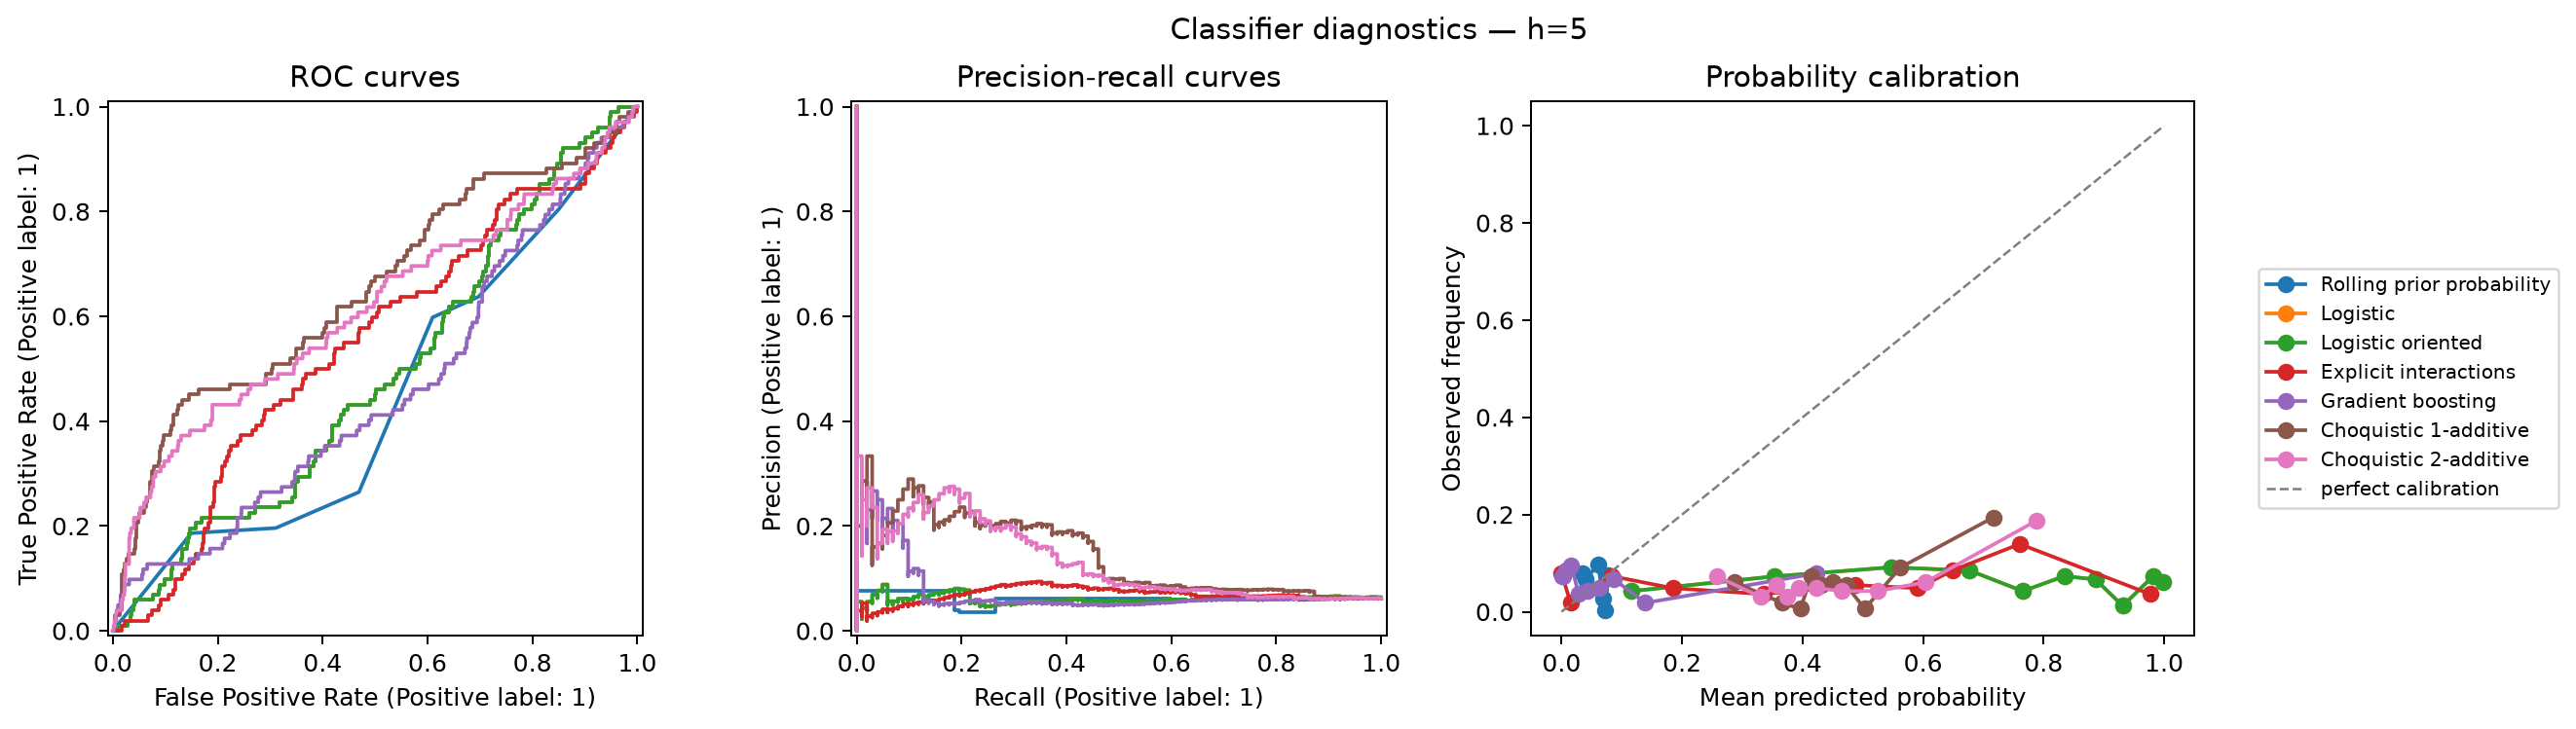

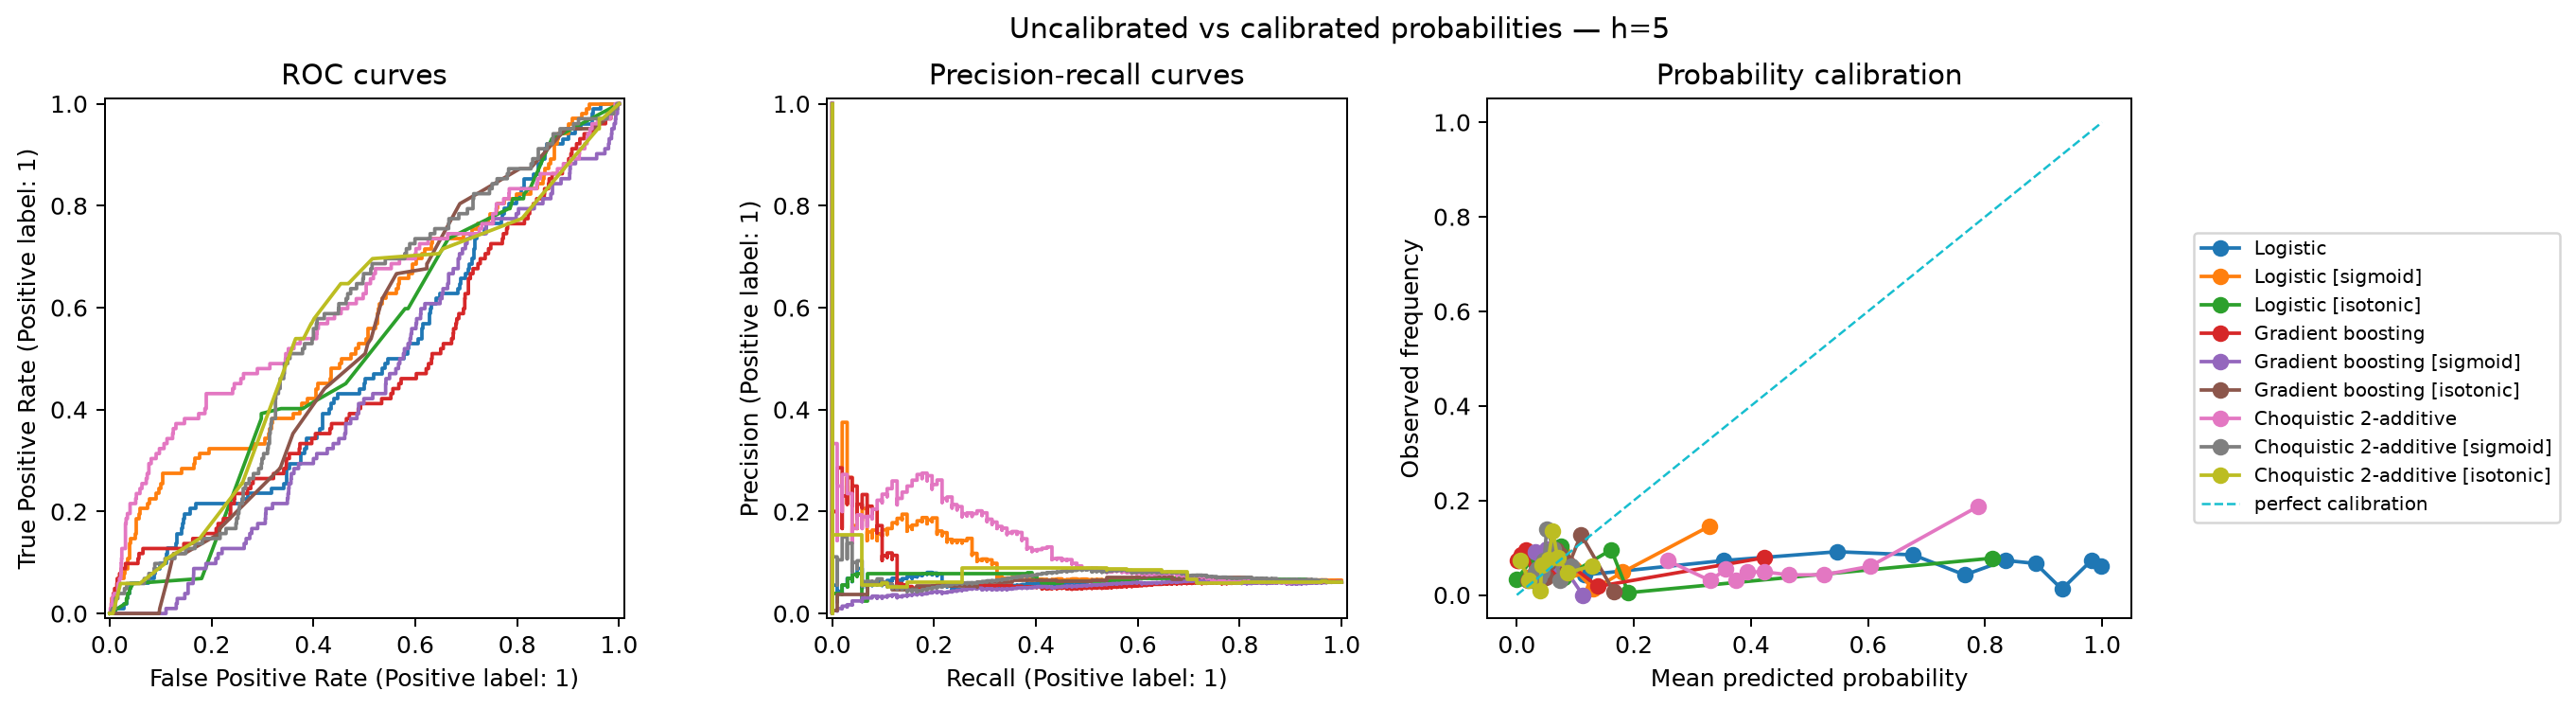

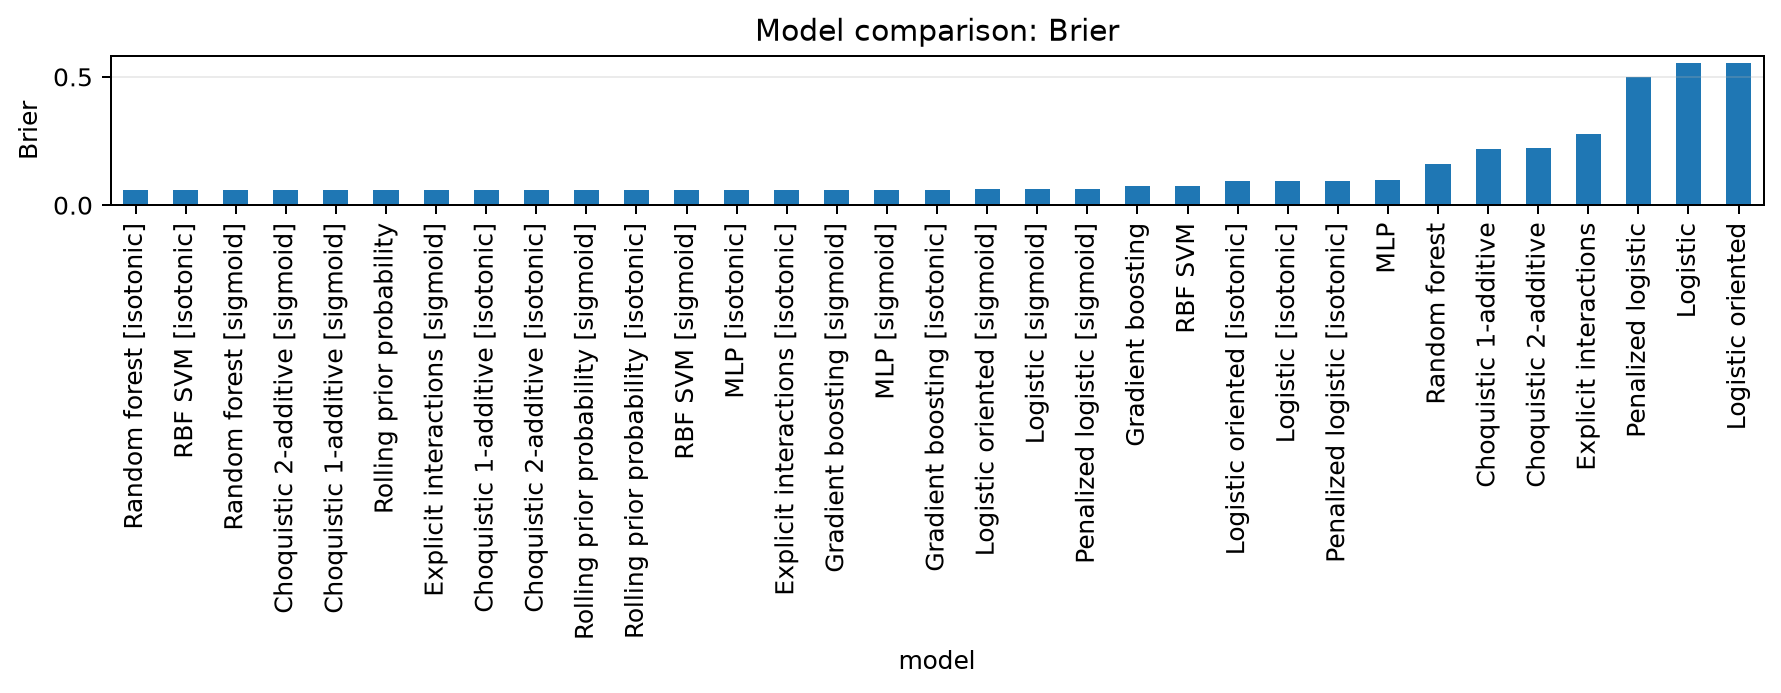

### Probability paths and classification decisions
Locate event clusters, probability responses and the errors summarized by confusion matrices.

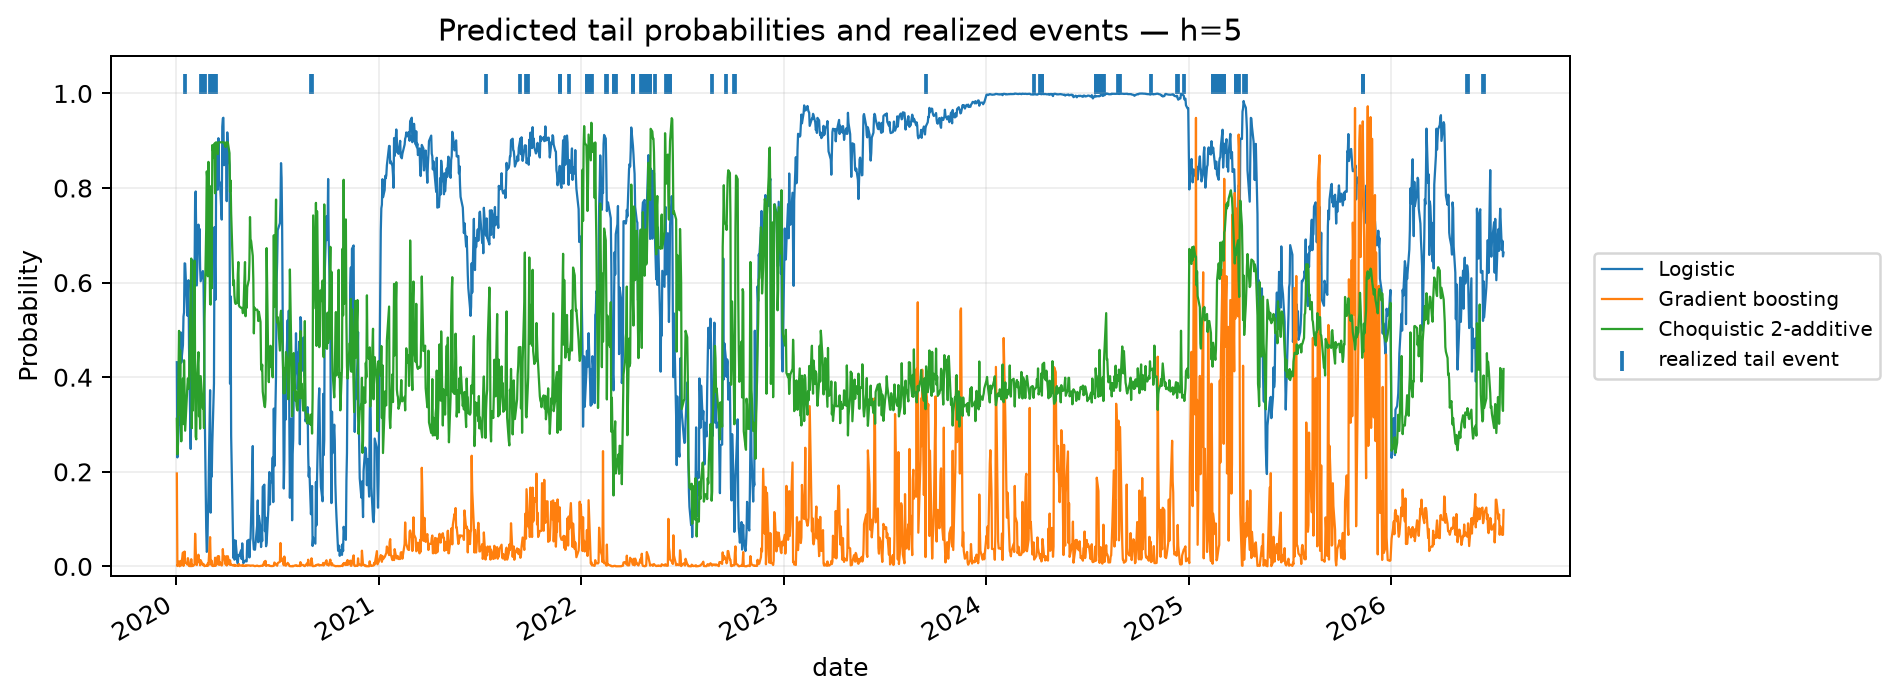

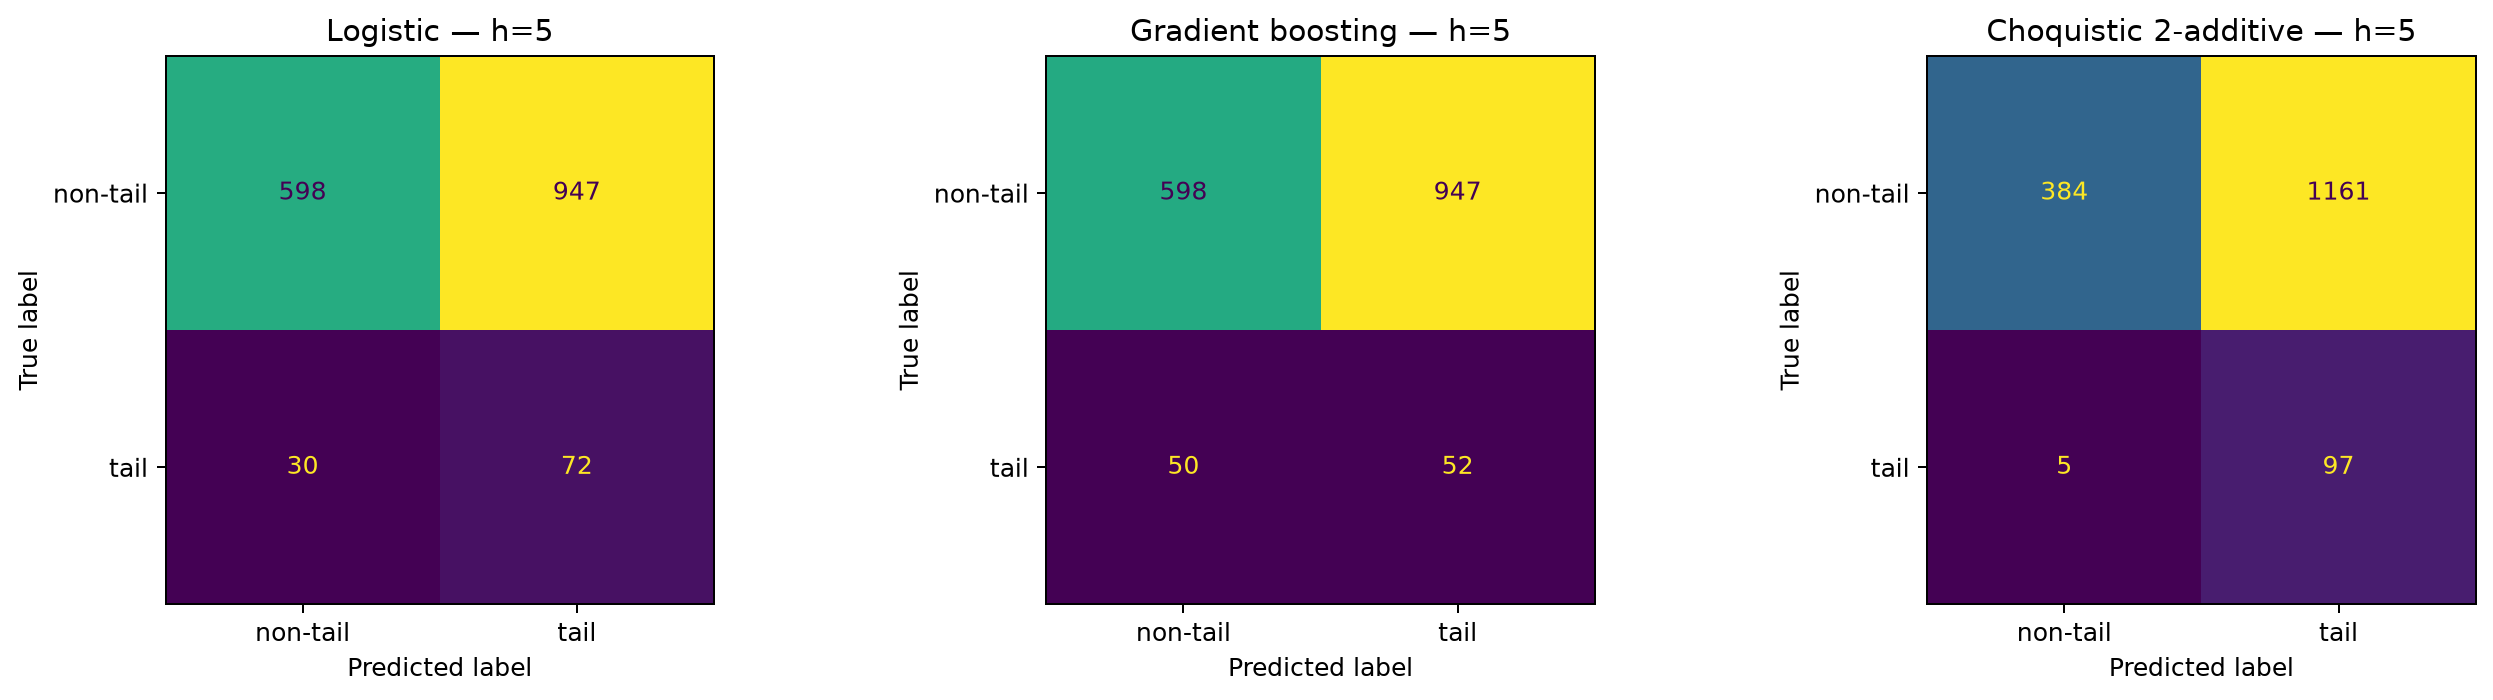

In [3]:
display(Markdown("### Complete OOS metrics by horizon\nStart with the combined view of discrimination, calibration and threshold-dependent classification."))
display(load_result_table("experiment_2b_classification_metrics_h1_a095.csv", index_col=0))
display(load_result_table("experiment_2b_classification_metrics_h5_a095.csv", index_col=0))
display(load_result_table("experiment_2b_classification_metrics_h10_a095.csv", index_col=0))
display(Markdown("### Walk-forward chronology and fold metrics\nAudit the past-only windows and see whether performance is concentrated in particular OOS years."))
display(load_result_table("experiment_2b_walk_forward_folds_h5_a095.csv", index_col=0))
display(load_result_table("experiment_2b_walk_forward_metrics_h5_a095.csv", index_col=[0, 1]))
display(Markdown("### Re-estimation history\nConfirm that orientation and Choquistic importance are recomputed for every rolling window."))
display(load_result_table("experiment_2b_orientation_history_h5_a095.csv", index_col=[0, 1, 2]))
display(load_result_table("experiment_2b_shapley_history_h5_a095.csv", index_col=[0, 1, 2]))
display(Markdown("### Discrimination: ROC-AUC and PR-AUC\nEvaluate ranking ability separately from the numerical quality of predicted probabilities."))
display(load_result_table("experiment_2b_discrimination_h1_a095.csv", index_col=0))
display(load_result_table("experiment_2b_discrimination_h5_a095.csv", index_col=0))
display(load_result_table("experiment_2b_discrimination_h10_a095.csv", index_col=0))
display(Markdown("### Calibration: Brier, log loss and prevalence alignment\nCompare uncalibrated, sigmoid and isotonic probabilities without conflating them with discrimination."))
display(load_result_table("experiment_2b_calibration_h1_a095.csv", index_col=0))
display(load_result_table("experiment_2b_calibration_h5_a095.csv", index_col=0))
display(load_result_table("experiment_2b_calibration_h10_a095.csv", index_col=0))
display(Markdown("### Calibration-sample audit\nCheck observations, dates and event prevalence used to calibrate each fold before its OOS year."))
display(load_result_table("experiment_2b_calibration_sample_h5_a095.csv", index_col=0))
display(Markdown("### Orientation ablation\nSeparate the effect of feature orientation from monotonicity and Choquistic interactions."))
display(load_result_table("experiment_2b_orientation_ablation_h1_a095.csv", index_col=0))
display(load_result_table("experiment_2b_orientation_ablation_h5_a095.csv", index_col=0))
display(load_result_table("experiment_2b_orientation_ablation_h10_a095.csv", index_col=0))
display(Markdown("### Ranking and calibration diagnostics\nInspect full ROC/PR curves, reliability behavior and Brier rankings beyond scalar summaries."))
display(Image(filename=result_figure_path("experiment_2b_classifier_diagnostics_h5_a095.png")))
display(Image(filename=result_figure_path("experiment_2b_calibration_comparison_h5_a095.png")))
display(Image(filename=result_figure_path("experiment_2b_brier_ranking_h5_a095.png")))
display(Markdown("### Probability paths and classification decisions\nLocate event clusters, probability responses and the errors summarized by confusion matrices."))
display(Image(filename=result_figure_path("experiment_2b_probability_paths_h5_a095.png")))
display(Image(filename=result_figure_path("experiment_2b_confusion_matrices_h5_a095.png")))

## Choquistic capacity and stability

### Final-window Choquistic interpretation
Use Shapley values and leading pairwise interactions to explain the latest fitted capacity.

,Shapley importance
vix,3.897783e-01
negative_momentum_21d,2.689966e-01
term_spread_10y_2y_pct,2.133408e-01
realized_volatility_20d,8.146734e-02
lagged_portfolio_loss_1d,2.875437e-02
market_loss_1d,1.766263e-02
liquidity_stress_20d,-1.342072e-15
baa_credit_spread_pct,-1.538909e-15
average_equity_correlation_60d,-2.001072e-15
drawdown_severity,-2.223738e-15


,first,second,interaction,interpretation
0,vix,term_spread_10y_2y_pct,4.266816e-01,complementary
1,vix,negative_momentum_21d,3.175497e-01,complementary
2,realized_volatility_20d,negative_momentum_21d,1.629347e-01,complementary
3,negative_momentum_21d,lagged_portfolio_loss_1d,5.750874e-02,complementary
4,market_loss_1d,vix,3.532525e-02,complementary
5,realized_volatility_20d,term_spread_10y_2y_pct,-3.883905e-15,redundant
6,vix,realized_volatility_20d,2.148292e-15,complementary
7,liquidity_stress_20d,baa_credit_spread_pct,1.558606e-15,complementary
8,liquidity_stress_20d,negative_momentum_21d,1.254620e-15,complementary
9,market_loss_1d,negative_momentum_21d,1.079611e-15,complementary


### Expanding-sample stability
Check whether the importance profile persists as the estimation history grows.

,average_equity_correlation_60d,baa_credit_spread_pct,drawdown_severity,lagged_portfolio_loss_1d,liquidity_stress_20d,market_loss_1d,negative_momentum_21d,realized_volatility_20d,term_spread_10y_2y_pct,vix
2018-12-31,1.760608e-01,1.075736e-16,1.061014e-15,2.478258e-01,2.457405e-16,0.076113,0.126489,0.373511,3.026215e-16,1.771063e-16
2020-12-31,3.042113e-02,-1.046272e-15,-1.920809e-15,7.937796e-03,-1.248186e-15,0.029327,0.690823,0.241490,-7.536060e-16,-1.201762e-15
2022-12-30,-4.509891e-16,6.285120e-16,2.967315e-17,6.241573e-16,7.719518e-16,0.073715,0.309254,0.255066,3.619656e-01,1.614645e-16
2024-12-31,-4.715640e-16,-1.179797e-15,-8.671678e-16,-2.385926e-16,-1.398789e-15,0.075466,0.317461,0.182539,4.245341e-01,-1.445584e-16
2026-07-30,-1.591812e-15,-1.864014e-15,-8.316382e-16,-6.301402e-16,-1.805521e-15,0.085972,0.285052,0.214948,4.140276e-01,-9.045560e-16


### Capacity visualizations
The plots summarize importance, interaction structure and stability in a more readable form.

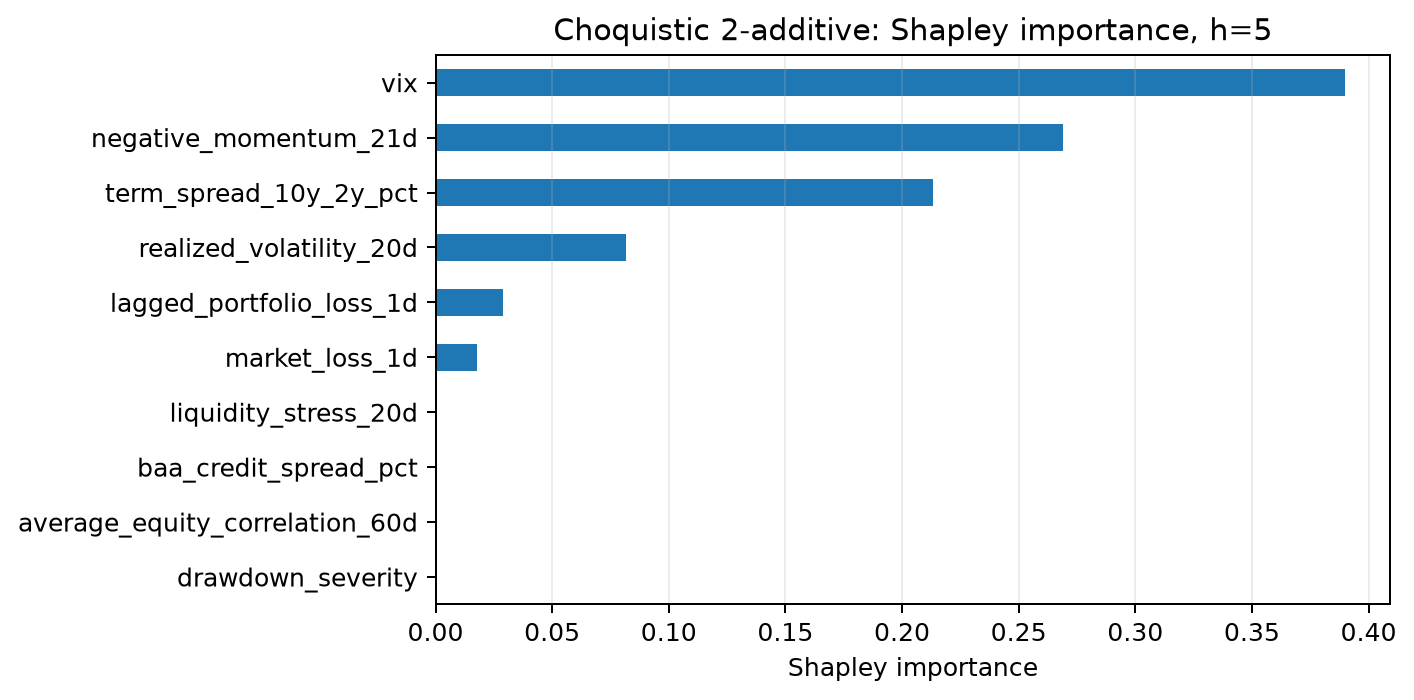

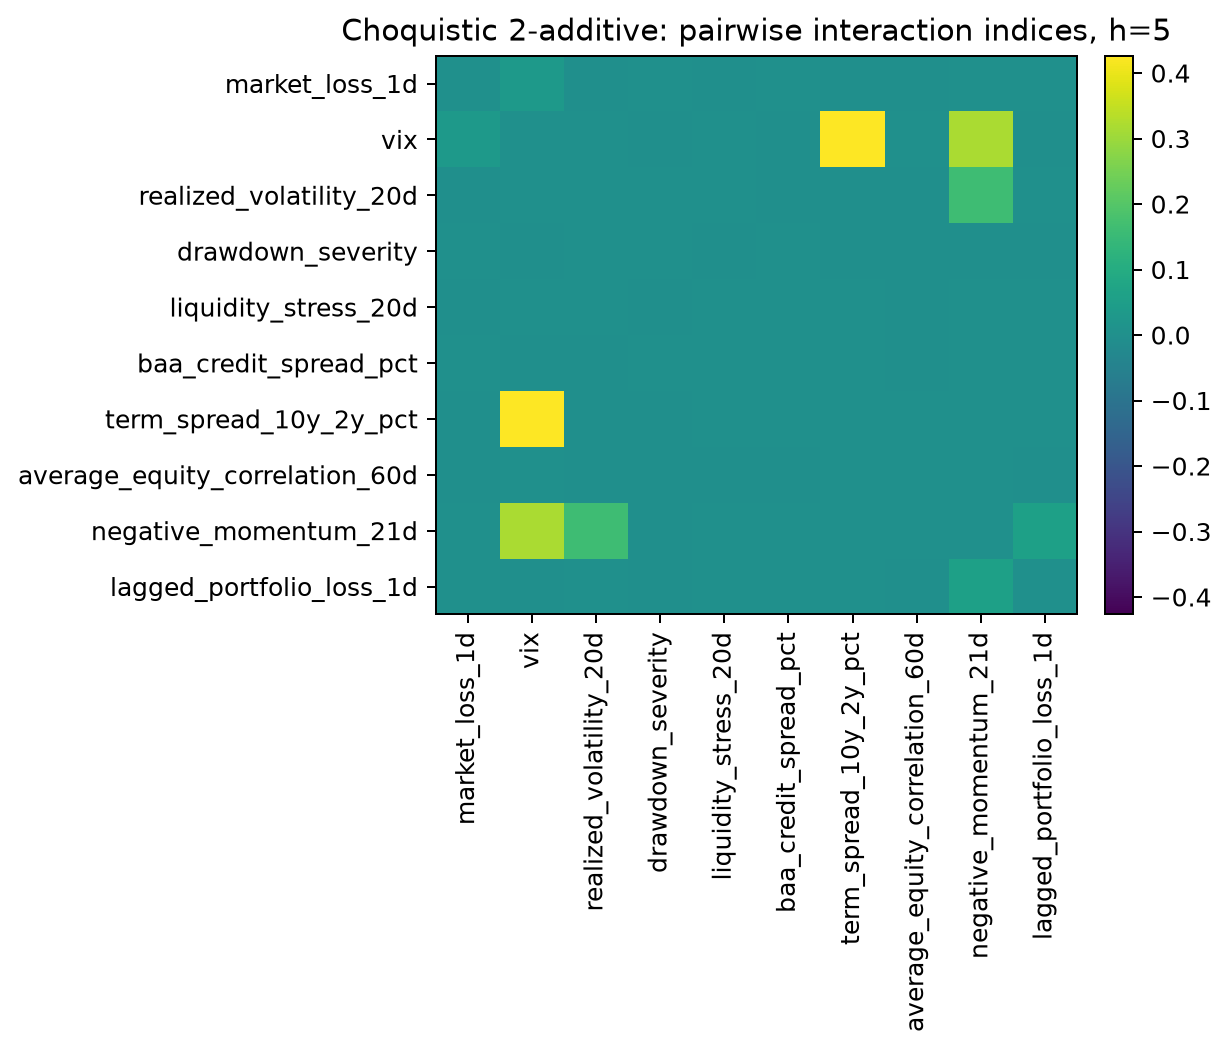

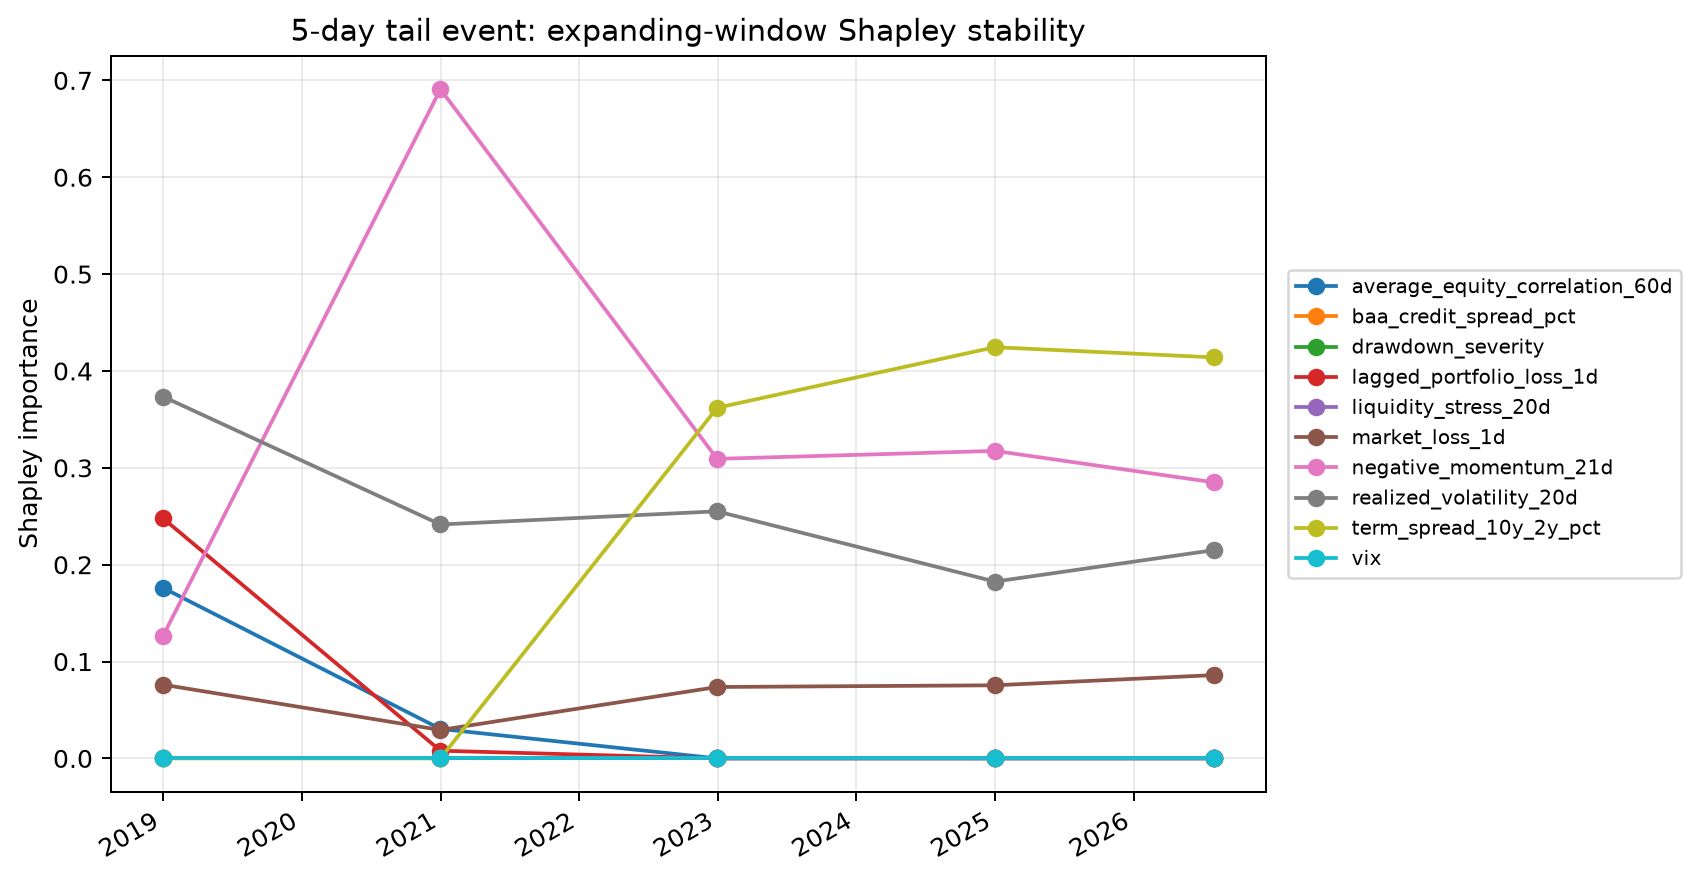

In [4]:
display(Markdown("### Final-window Choquistic interpretation\nUse Shapley values and leading pairwise interactions to explain the latest fitted capacity."))
display(load_result_table("experiment_2b_shapley_h5_choquistic_2-additive.csv", index_col=0))
display(load_result_table("experiment_2b_top_interactions_h5_choquistic_2_additive.csv"))
display(Markdown("### Expanding-sample stability\nCheck whether the importance profile persists as the estimation history grows."))
display(load_result_table("experiment_2b_shapley_stability_h5_a095.csv", index_col=0))
display(Markdown("### Capacity visualizations\nThe plots summarize importance, interaction structure and stability in a more readable form."))
display(Image(filename=result_figure_path("experiment_2b_shapley_h5_choquistic_2_additive.png")))
display(Image(filename=result_figure_path("experiment_2b_interactions_h5_choquistic_2_additive.png")))
display(Image(filename=result_figure_path("experiment_2b_shapley_stability_h5_a095.png")))

## Robustness to rarer events at 97.5%

The same frozen-pipeline calibration design is repeated for the rarer event definition.

In [5]:
display(Markdown("### Complete metrics for rarer events\nCheck whether model rankings survive when positives become substantially less frequent."))
display(load_result_table("experiment_2b_classification_metrics_h1_a0975.csv", index_col=0))
display(load_result_table("experiment_2b_classification_metrics_h5_a0975.csv", index_col=0))
display(load_result_table("experiment_2b_classification_metrics_h10_a0975.csv", index_col=0))
display(Markdown("### Rare-event discrimination\nCompare ROC-AUC and especially PR-AUC under the more severe class imbalance."))
display(load_result_table("experiment_2b_discrimination_h1_a0975.csv", index_col=0))
display(load_result_table("experiment_2b_discrimination_h5_a0975.csv", index_col=0))
display(load_result_table("experiment_2b_discrimination_h10_a0975.csv", index_col=0))
display(Markdown("### Rare-event calibration\nAssess whether calibrated probabilities track the lower prevalence without excessive log-loss penalties."))
display(load_result_table("experiment_2b_calibration_h1_a0975.csv", index_col=0))
display(load_result_table("experiment_2b_calibration_h5_a0975.csv", index_col=0))
display(load_result_table("experiment_2b_calibration_h10_a0975.csv", index_col=0))
display(Markdown("### Rare-event calibration samples\nVerify that every historical calibration block contains enough events and remains strictly pre-OOS."))
display(load_result_table("experiment_2b_calibration_sample_h5_a0975.csv", index_col=0))
display(Markdown("### Rare-event orientation ablation\nCheck whether conclusions about orientation remain valid at the 97.5% event definition."))
display(load_result_table("experiment_2b_orientation_ablation_h1_a0975.csv", index_col=0))
display(load_result_table("experiment_2b_orientation_ablation_h5_a0975.csv", index_col=0))
display(load_result_table("experiment_2b_orientation_ablation_h10_a0975.csv", index_col=0))

### Complete metrics for rarer events
Check whether model rankings survive when positives become substantially less frequent.

,base model,probability calibration,threshold source,ROC AUC,PR AUC,Precision,Recall,F1,Brier,Log loss,...,Predicted event rate,Observed event rate,validation PR AUC,selection runtime seconds,refit runtime seconds,calibration runtime seconds,parameter count,calibration observations,calibration event prevalence,OOS folds
model,,,,,,,,,,,,,,,,,,,,,
Choquistic 2-additive,Choquistic 2-additive,uncalibrated,selection validation,0.742028,0.120482,0.051546,0.740741,0.096386,0.188550,0.584743,...,0.470018,0.032707,0.073331,7.537421,7.607028,0.000000,57.0,3514,0.032726,7
Choquistic 2-additive [sigmoid],Choquistic 2-additive,sigmoid,calibration,0.686461,0.103949,0.095477,0.351852,0.150198,0.031207,0.136377,...,0.120533,0.032707,0.073331,7.537421,7.607028,0.098165,57.0,3514,0.032726,7
Choquistic 1-additive [isotonic],Choquistic 1-additive,isotonic,calibration,0.705060,0.077540,0.122137,0.296296,0.172973,0.031222,0.164048,...,0.079346,0.032707,0.059569,1.997729,1.677686,0.084704,12.0,3514,0.032726,7
Choquistic 1-additive,Choquistic 1-additive,uncalibrated,selection validation,0.712917,0.074036,0.064309,0.740741,0.118343,0.248928,0.733714,...,0.376741,0.032707,0.059569,1.997729,1.677686,0.000000,12.0,3514,0.032726,7
Penalized logistic [sigmoid],Penalized logistic,sigmoid,calibration,0.647638,0.072057,0.061224,0.611111,0.111298,0.031461,0.139914,...,0.326469,0.032707,0.079135,0.219538,0.041777,0.071125,11.0,3514,0.032726,7
Choquistic 1-additive [sigmoid],Choquistic 1-additive,sigmoid,calibration,0.667009,0.070569,0.122137,0.296296,0.172973,0.031318,0.139101,...,0.079346,0.032707,0.059569,1.997729,1.677686,0.090332,12.0,3514,0.032726,7
Penalized logistic [isotonic],Penalized logistic,isotonic,calibration,0.668487,0.067653,0.085246,0.481481,0.144847,0.031403,0.221031,...,0.184737,0.032707,0.079135,0.219538,0.041777,0.065956,11.0,3514,0.032726,7
Logistic,Logistic,uncalibrated,selection validation,0.624272,0.064264,0.055556,0.537037,0.100694,0.523686,1.582459,...,0.316172,0.032707,0.058127,0.067205,0.050814,0.000000,11.0,3514,0.032726,7
Logistic oriented,Logistic oriented,uncalibrated,selection validation,0.624272,0.064264,0.055556,0.537037,0.100694,0.523686,1.582459,...,0.316172,0.032707,0.058127,0.081993,0.056187,0.000000,11.0,3514,0.032726,7


,base model,probability calibration,threshold source,ROC AUC,PR AUC,Precision,Recall,F1,Brier,Log loss,...,Predicted event rate,Observed event rate,validation PR AUC,selection runtime seconds,refit runtime seconds,calibration runtime seconds,parameter count,calibration observations,calibration event prevalence,OOS folds
model,,,,,,,,,,,,,,,,,,,,,
Choquistic 1-additive,Choquistic 1-additive,uncalibrated,selection validation,0.652698,0.087552,0.053502,0.873016,0.100825,0.221423,0.640119,...,0.624165,0.038251,0.038109,2.322493,1.789513,0.000000,12.0,3486,0.03759,7
Choquistic 2-additive,Choquistic 2-additive,uncalibrated,selection validation,0.614037,0.086628,0.050573,0.841270,0.095410,0.209493,0.614664,...,0.636308,0.038251,0.048807,13.004966,8.064396,0.000000,57.0,3486,0.03759,7
Choquistic 2-additive [isotonic],Choquistic 2-additive,isotonic,calibration,0.629534,0.082950,0.092369,0.365079,0.147436,0.036277,0.240975,...,0.151184,0.038251,0.048807,13.004966,8.064396,0.087301,57.0,3486,0.03759,7
Choquistic 2-additive [sigmoid],Choquistic 2-additive,sigmoid,calibration,0.593970,0.062934,0.094595,0.222222,0.132701,0.036627,0.160173,...,0.089860,0.038251,0.048807,13.004966,8.064396,0.095993,57.0,3486,0.03759,7
Choquistic 1-additive [isotonic],Choquistic 1-additive,isotonic,calibration,0.591390,0.057557,0.078014,0.523810,0.135802,0.036915,0.329171,...,0.256831,0.038251,0.038109,2.322493,1.789513,0.153377,12.0,3486,0.03759,7
Logistic [sigmoid],Logistic,sigmoid,calibration,0.497264,0.052466,0.038335,0.555556,0.071721,0.049921,0.201134,...,0.554341,0.038251,0.039962,0.084536,0.054053,0.077452,11.0,3486,0.03759,7
Logistic oriented [sigmoid],Logistic oriented,sigmoid,calibration,0.497264,0.052466,0.038335,0.555556,0.071721,0.049921,0.201134,...,0.554341,0.038251,0.039962,0.091576,0.060350,0.088825,11.0,3486,0.03759,7
Choquistic 1-additive [sigmoid],Choquistic 1-additive,sigmoid,calibration,0.562550,0.051774,0.065263,0.492063,0.115242,0.036760,0.161885,...,0.288403,0.038251,0.038109,2.322493,1.789513,0.093290,12.0,3486,0.03759,7
Logistic [isotonic],Logistic,isotonic,calibration,0.535769,0.049828,0.044146,0.730159,0.083258,0.040626,0.250021,...,0.632665,0.038251,0.039962,0.084536,0.054053,0.086898,11.0,3486,0.03759,7


,base model,probability calibration,threshold source,ROC AUC,PR AUC,Precision,Recall,F1,Brier,Log loss,...,Predicted event rate,Observed event rate,validation PR AUC,selection runtime seconds,refit runtime seconds,calibration runtime seconds,parameter count,calibration observations,calibration event prevalence,OOS folds
model,,,,,,,,,,,,,,,,,,,,,
Choquistic 2-additive,Choquistic 2-additive,uncalibrated,selection validation,0.549047,0.114798,0.066402,0.807229,0.122711,0.203687,0.616787,...,0.614495,0.050548,0.043161,7.921317,7.723426,0.000000,57.0,3451,0.048109,7
Choquistic 1-additive,Choquistic 1-additive,uncalibrated,selection validation,0.576822,0.107882,0.052147,0.819277,0.098053,0.226322,0.650638,...,0.794153,0.050548,0.044428,2.190904,1.895817,0.000000,12.0,3451,0.048109,7
Penalized logistic [sigmoid],Penalized logistic,sigmoid,calibration,0.611482,0.095731,0.064729,0.590361,0.116667,0.051506,0.208863,...,0.461023,0.050548,0.108905,0.223401,0.046972,0.084395,11.0,3451,0.048109,7
Penalized logistic [isotonic],Penalized logistic,isotonic,calibration,0.582096,0.078750,0.061632,0.855422,0.114980,0.050003,0.350144,...,0.701583,0.050548,0.108905,0.223401,0.046972,0.066128,11.0,3451,0.048109,7
Logistic [sigmoid],Logistic,sigmoid,calibration,0.579967,0.078744,0.057196,0.746988,0.106255,0.110033,0.378899,...,0.660171,0.050548,0.053908,0.080607,0.062316,0.083773,11.0,3451,0.048109,7
Logistic oriented [sigmoid],Logistic oriented,sigmoid,calibration,0.579967,0.078744,0.057196,0.746988,0.106255,0.110033,0.378899,...,0.660171,0.050548,0.053908,0.090095,0.059500,0.088861,11.0,3451,0.048109,7
Choquistic 1-additive [isotonic],Choquistic 1-additive,isotonic,calibration,0.586938,0.077860,0.074541,0.783133,0.136126,0.052257,0.312643,...,0.531060,0.050548,0.044428,2.190904,1.895817,0.082946,12.0,3451,0.048109,7
Gradient boosting [isotonic],Gradient boosting,isotonic,calibration,0.621011,0.072147,0.106250,0.614458,0.181172,0.047836,0.253232,...,0.292326,0.050548,0.118715,4.237142,0.740265,0.144474,NaN,3451,0.048109,7
Gradient boosting,Gradient boosting,uncalibrated,selection validation,0.552358,0.070386,0.045566,0.674699,0.085366,0.051757,0.276875,...,0.748477,0.050548,0.118715,4.237142,0.740265,0.000000,NaN,3451,0.048109,7


### Rare-event discrimination
Compare ROC-AUC and especially PR-AUC under the more severe class imbalance.

...

,sample,observations,start,end,events,event prevalence
fold,,,,,,
0,OOS,253,2020-01-02,2020-12-31,13,0.051383
0,calibration,498,2018-01-02,2019-12-23,24,0.048193
0,selection_validation,373,2016-07-01,2017-12-21,4,0.010724
0,train,370,2015-01-06,2016-06-23,13,0.035135
1,OOS,252,2021-01-04,2021-12-31,2,0.007937
1,calibration,500,2019-01-02,2020-12-23,14,0.028000
1,selection_validation,372,2017-07-03,2018-12-21,27,0.072581
1,train,372,2016-01-04,2017-06-23,4,0.010753
2,OOS,251,2022-01-03,2022-12-30,19,0.075697


### Rare-event orientation ablation
Check whether conclusions about orientation remain valid at the 97.5% event definition.

,base model,probability calibration,threshold source,ROC AUC,PR AUC,Precision,Recall,F1,Brier,Log loss,...,Predicted event rate,Observed event rate,validation PR AUC,selection runtime seconds,refit runtime seconds,calibration runtime seconds,parameter count,calibration observations,calibration event prevalence,OOS folds
model,,,,,,,,,,,,,,,,,,,,,
Choquistic 2-additive,Choquistic 2-additive,uncalibrated,selection validation,0.742028,0.120482,0.051546,0.740741,0.096386,0.188550,0.584743,...,0.470018,0.032707,0.073331,7.537421,7.607028,0.0,57.0,3514,0.032726,7
Choquistic 1-additive,Choquistic 1-additive,uncalibrated,selection validation,0.712917,0.074036,0.064309,0.740741,0.118343,0.248928,0.733714,...,0.376741,0.032707,0.059569,1.997729,1.677686,0.0,12.0,3514,0.032726,7
Logistic,Logistic,uncalibrated,selection validation,0.624272,0.064264,0.055556,0.537037,0.100694,0.523686,1.582459,...,0.316172,0.032707,0.058127,0.067205,0.050814,0.0,11.0,3514,0.032726,7
Logistic oriented,Logistic oriented,uncalibrated,selection validation,0.624272,0.064264,0.055556,0.537037,0.100694,0.523686,1.582459,...,0.316172,0.032707,0.058127,0.081993,0.056187,0.0,11.0,3514,0.032726,7


,base model,probability calibration,threshold source,ROC AUC,PR AUC,Precision,Recall,F1,Brier,Log loss,...,Predicted event rate,Observed event rate,validation PR AUC,selection runtime seconds,refit runtime seconds,calibration runtime seconds,parameter count,calibration observations,calibration event prevalence,OOS folds
model,,,,,,,,,,,,,,,,,,,,,
Choquistic 1-additive,Choquistic 1-additive,uncalibrated,selection validation,0.652698,0.087552,0.053502,0.873016,0.100825,0.221423,0.640119,...,0.624165,0.038251,0.038109,2.322493,1.789513,0.0,12.0,3486,0.03759,7
Choquistic 2-additive,Choquistic 2-additive,uncalibrated,selection validation,0.614037,0.086628,0.050573,0.841270,0.095410,0.209493,0.614664,...,0.636308,0.038251,0.048807,13.004966,8.064396,0.0,57.0,3486,0.03759,7
Logistic oriented,Logistic oriented,uncalibrated,selection validation,0.457061,0.039872,0.038509,1.000000,0.074161,0.582931,2.460870,...,0.993321,0.038251,0.039962,0.091576,0.060350,0.0,11.0,3486,0.03759,7
Logistic,Logistic,uncalibrated,selection validation,0.457061,0.039872,0.038509,1.000000,0.074161,0.582931,2.460870,...,0.993321,0.038251,0.039962,0.084536,0.054053,0.0,11.0,3486,0.03759,7


,base model,probability calibration,threshold source,ROC AUC,PR AUC,Precision,Recall,F1,Brier,Log loss,...,Predicted event rate,Observed event rate,validation PR AUC,selection runtime seconds,refit runtime seconds,calibration runtime seconds,parameter count,calibration observations,calibration event prevalence,OOS folds
model,,,,,,,,,,,,,,,,,,,,,
Choquistic 2-additive,Choquistic 2-additive,uncalibrated,selection validation,0.549047,0.114798,0.066402,0.807229,0.122711,0.203687,0.616787,...,0.614495,0.050548,0.043161,7.921317,7.723426,0.0,57.0,3451,0.048109,7
Choquistic 1-additive,Choquistic 1-additive,uncalibrated,selection validation,0.576822,0.107882,0.052147,0.819277,0.098053,0.226322,0.650638,...,0.794153,0.050548,0.044428,2.190904,1.895817,0.0,12.0,3451,0.048109,7
Logistic,Logistic,uncalibrated,selection validation,0.391702,0.039291,0.050765,1.000000,0.096624,0.574839,4.271725,...,0.995737,0.050548,0.053908,0.080607,0.062316,0.0,11.0,3451,0.048109,7
Logistic oriented,Logistic oriented,uncalibrated,selection validation,0.391702,0.039291,0.050765,1.000000,0.096624,0.574839,4.271725,...,0.995737,0.050548,0.053908,0.090095,0.059500,0.0,11.0,3451,0.048109,7
